# 전자상거래 배송 지연 분석 — 룰베이스 분류 도출

## 분석 시나리오
한 국제 전자상거래 회사가 전자제품을 판매한다. 최근 배송 지연이 많아져 고객 불만이 쌓이고 있다.
당신은 데이터 분석 담당자로서 **어떤 조건에서 지연이 발생하는지** 찾아내고, 단순한 룰만으로 지연 가능성을 예측할 수 있는지 확인해야 한다.

## 분석 흐름
1. **데이터 파악** — 컬럼, 타입, 분포 확인
2. **시각화 탐색**  — 단변량/타겟별 분포 비교
3. **인사이트 정리**  — 강한 시그널 vs 약한 시그널
4. **룰 도출 및 검증** — 룰1, 룰2 정의 후 정확도/혼동행렬 확인
5. **잔여 영역 심화 분석**  — 잔여 영역에서 룰3 발견 + 3개 룰 종합 평가

## 데이터
- 파일: `배송데이터_전체.csv` (10,999행, 11개 컬럼)
- 타겟: `배송결과` (`지연` / `정시`)

---

## 0. 환경 준비

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 자동 감지 (환경에 설치된 첫 번째 한글 폰트 사용)
candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic',
              'Noto Sans CJK KR', 'Noto Sans KR', 'DejaVu Sans']
available = {f.name for f in fm.fontManager.ttflist}
for font in candidates:
    if font in available:
        plt.rcParams['font.family'] = font
        break
plt.rcParams['axes.unicode_minus'] = False

sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
pd.set_option('display.max_columns', None)

---
## 1. 데이터 파악

### 과제 1-1. 데이터를 불러오고 모양과 처음 5행을 확인하시오.

In [ ]:
import pandas as pd

# 1. 데이터 불러오기
df = pd.read_csv("배송데이터_전체.csv")

# 2. 데이터 모양 확인 (행, 열)
print("데이터 shape:", df.shape)

# 3. 상위 5개 행 확인
print("\n상위 5개 행:")
print(df.head())


데이터 shape: (10999, 11)

상위 5개 행:
  창고블록 배송수단  문의전화수  고객평점  상품가격  이전구매횟수 상품중요도 성별  할인율  무게_그램 배송결과
0    D   항공      4     2   177       3     하  여   44   1233   지연
1    F   항공      4     5   216       2     하  남   59   3088   지연
2    A   항공      2     2   183       4     하  남   48   3374   지연
3    B   항공      3     3   176       4     중  남   10   1177   지연
4    C   항공      2     2   184       3     중  여   46   2484   지연


**해석:** 10,999행 × 11개 컬럼. 각 행은 한 건의 배송 주문을 의미한다.

### 과제 1-2. 각 컬럼의 데이터 타입과 결측치를 확인하시오.

In [ ]:
# 1. 컬럼별 데이터 타입 확인
print("컬럼별 데이터 타입:")
print(df.dtypes)

# ------------------------------

# 2. 결측치 개수 확인
print("\n컬럼별 결측치 개수:")
print(df.isnull().sum())

# ------------------------------

# 3. 한 번에 요약해서 보기 (추천)
print("\n데이터 전체 요약:")
print(df.info())


컬럼별 데이터 타입:
창고블록      object
배송수단      object
문의전화수      int64
고객평점       int64
상품가격       int64
이전구매횟수     int64
상품중요도     object
성별        object
할인율        int64
무게_그램      int64
배송결과      object
dtype: object

컬럼별 결측치 개수:
창고블록      0
배송수단      0
문의전화수     0
고객평점      0
상품가격      0
이전구매횟수    0
상품중요도     0
성별        0
할인율       0
무게_그램     0
배송결과      0
dtype: int64

데이터 전체 요약:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   창고블록    10999 non-null  object
 1   배송수단    10999 non-null  object
 2   문의전화수   10999 non-null  int64 
 3   고객평점    10999 non-null  int64 
 4   상품가격    10999 non-null  int64 
 5   이전구매횟수  10999 non-null  int64 
 6   상품중요도   10999 non-null  object
 7   성별      10999 non-null  object
 8   할인율     10999 non-null  int64 
 9   무게_그램   10999 non-null  int64 
 10  배송결과    10999 non-null  object
dtypes: int64(6), object(5)
memory usage

**해석:**
결측치가 전혀 없는 완전한 데이터로, 추가적인 결측 처리 없이 바로 분석 가능하다.
수치형(6개)과 범주형(5개)이 명확히 구분되어 있어 전처리 구조가 단순하다.
배송결과가 범주형이므로 이후 분석이나 모델링 시 타겟 인코딩이 필요하다.

### 과제 1-3. 수치형 변수의 기초 통계량을 확인하시오.

In [ ]:
# 수치형 변수 기초 통계량
print(df.describe())

              문의전화수          고객평점          상품가격        이전구매횟수           할인율  \
count  10999.000000  10999.000000  10999.000000  10999.000000  10999.000000   
mean       4.054459      2.990545    210.196836      3.567597     13.373216   
std        1.141490      1.413603     48.063272      1.522860     16.205527   
min        2.000000      1.000000     96.000000      2.000000      1.000000   
25%        3.000000      2.000000    169.000000      3.000000      4.000000   
50%        4.000000      3.000000    214.000000      3.000000      7.000000   
75%        5.000000      4.000000    251.000000      4.000000     10.000000   
max        7.000000      5.000000    310.000000     10.000000     65.000000   

              무게_그램  
count  10999.000000  
mean    3634.016729  
std     1635.377251  
min     1001.000000  
25%     1839.500000  
50%     4149.000000  
75%     5050.000000  
max     7846.000000  


**해석:** 전반적으로 변수들이 극단값 없이 안정적인 분포를 보이며, 이상치 영향은 크지 않은 편이다.
할인율은 평균(13.3) 대비 최대값(65)이 커서 일부 고할인 케이스가 존재한다.
무게와 상품가격은 분산이 비교적 커, 배송 지연에 영향 줄 가능성이 높은 핵심 변수로 보인다.

### 과제 1-4. 타겟 변수 `배송결과`의 분포를 확인하시오. 클래스 불균형이 있는지 평가하시오.

In [ ]:
# 1. 클래스별 개수
print("클래스별 개수:")
print(df['배송결과'].value_counts())

# ------------------------------

# 2. 클래스별 비율
print("\n클래스별 비율:")
print(df['배송결과'].value_counts(normalize=True))

# ------------------------------

# 3. 불균형 여부 간단 판단
ratio = df['배송결과'].value_counts(normalize=True)

print("\n불균형 판단:")
if ratio.max() > 0.7:
    print("클래스 불균형 심함")
elif ratio.max() > 0.6:
    print("약한 불균형 존재")
else:
    print("균형 데이터")


클래스별 개수:
배송결과
지연    6563
정시    4436
Name: count, dtype: int64

클래스별 비율:
배송결과
지연    0.596691
정시    0.403309
Name: proportion, dtype: float64

불균형 판단:
균형 데이터


**해석:** 지연(약 59.7%)이 정시(약 40.3%)보다 많지만, 극단적인 클래스 불균형은 아니다.
모델링은 기본 설정으로도 가능하나, 약한 편향은 존재한다.
정밀한 예측이 필요하면 클래스 가중치 정도는 고려할 수 있다.

### 과제 1-5. 범주형 변수의 카테고리별 빈도를 시각화하여 확인하시오.

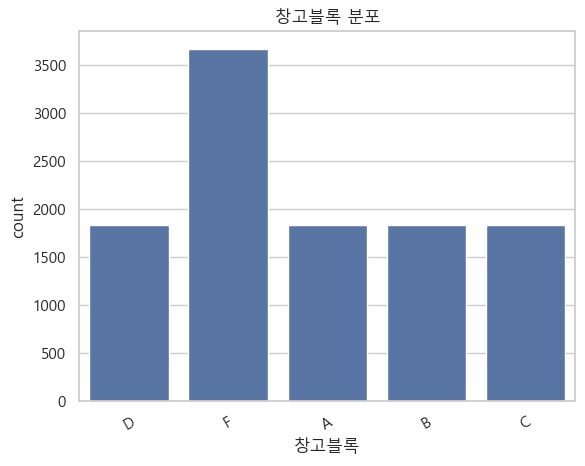

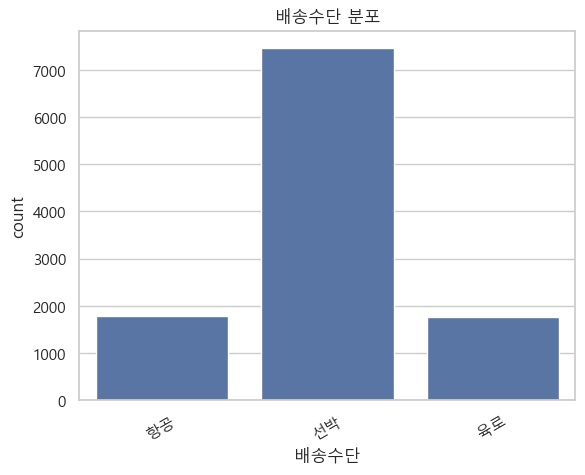

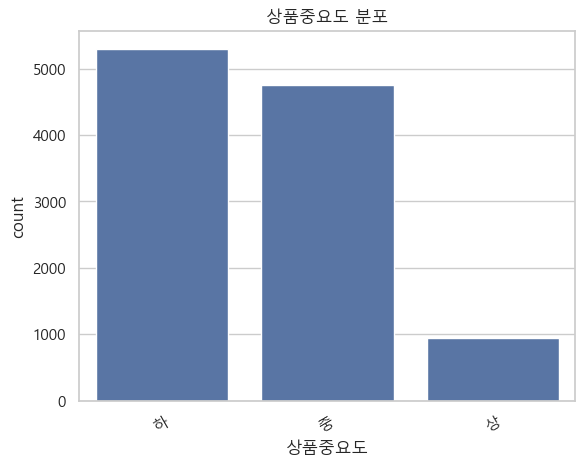

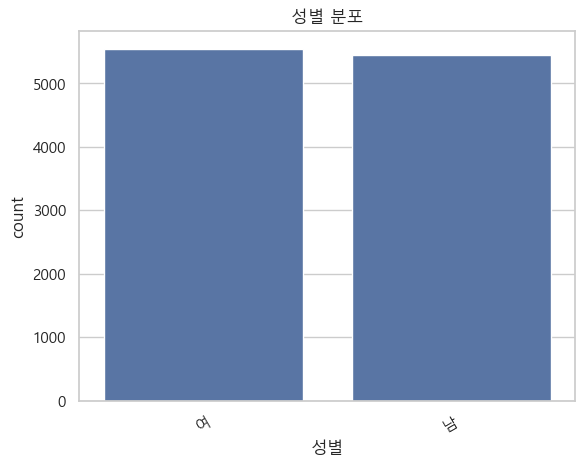

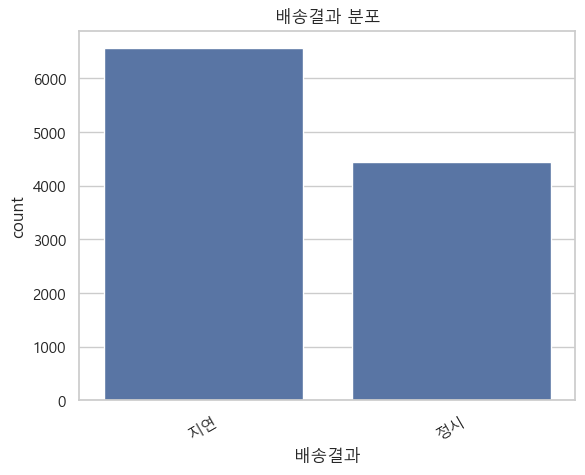

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 범주형 변수 리스트
cat_cols = ['창고블록', '배송수단', '상품중요도', '성별', '배송결과']

# 시각화
for col in cat_cols:
    plt.figure()
    sns.countplot(data=df, x=col)
    plt.title(f"{col} 분포")
    plt.xticks(rotation=30)
    plt.show()

In [ ]:
# 범주형 변수 리스트
cat_cols = ['창고블록', '배송수단', '상품중요도', '성별', '배송결과']

# 카테고리별 빈도 확인
for col in cat_cols:
    print(f"\n[{col} 카테고리별 개수]")
    print(df[col].value_counts())

    print(f"\n[{col} 카테고리별 비율]")
    print(df[col].value_counts(normalize=True))


[창고블록 카테고리별 개수]
창고블록
F    3666
D    1834
A    1833
B    1833
C    1833
Name: count, dtype: int64

[창고블록 카테고리별 비율]
창고블록
F    0.333303
D    0.166742
A    0.166652
B    0.166652
C    0.166652
Name: proportion, dtype: float64

[배송수단 카테고리별 개수]
배송수단
선박    7462
항공    1777
육로    1760
Name: count, dtype: int64

[배송수단 카테고리별 비율]
배송수단
선박    0.678425
항공    0.161560
육로    0.160015
Name: proportion, dtype: float64

[상품중요도 카테고리별 개수]
상품중요도
하    5297
중    4754
상     948
Name: count, dtype: int64

[상품중요도 카테고리별 비율]
상품중요도
하    0.481589
중    0.432221
상    0.086190
Name: proportion, dtype: float64

[성별 카테고리별 개수]
성별
여    5545
남    5454
Name: count, dtype: int64

[성별 카테고리별 비율]
성별
여    0.504137
남    0.495863
Name: proportion, dtype: float64

[배송결과 카테고리별 개수]
배송결과
지연    6563
정시    4436
Name: count, dtype: int64

[배송결과 카테고리별 비율]
배송결과
지연    0.596691
정시    0.403309
Name: proportion, dtype: float64


**해석:** 창고블록은 F가 다른 블록 대비 두 배 가까이 많고, 나머지(A, B, C, D)는 비교적 균등한 분포를 보입니다.
배송수단은 선박이 압도적으로 많아 데이터가 한쪽으로 치우쳐 있으며, 항공·육로는 비슷한 수준입니다.
상품중요도는 하와 중이 대부분이고, 상은 매우 적어 중요도 높은 상품은 소수입니다.
성별은 남녀 비율이 거의 동일하여 편향 없이 균형 잡힌 분포입니다.

---
## 2. 시각화 탐색

이제 각 피처가 `배송결과`와 어떤 관계가 있는지 살펴본다. 강한 관계가 있는 피처는 룰의 후보가 된다.

### 과제 2-1. 수치형 변수들의 분포(히스토그램)를 한눈에 보시오.

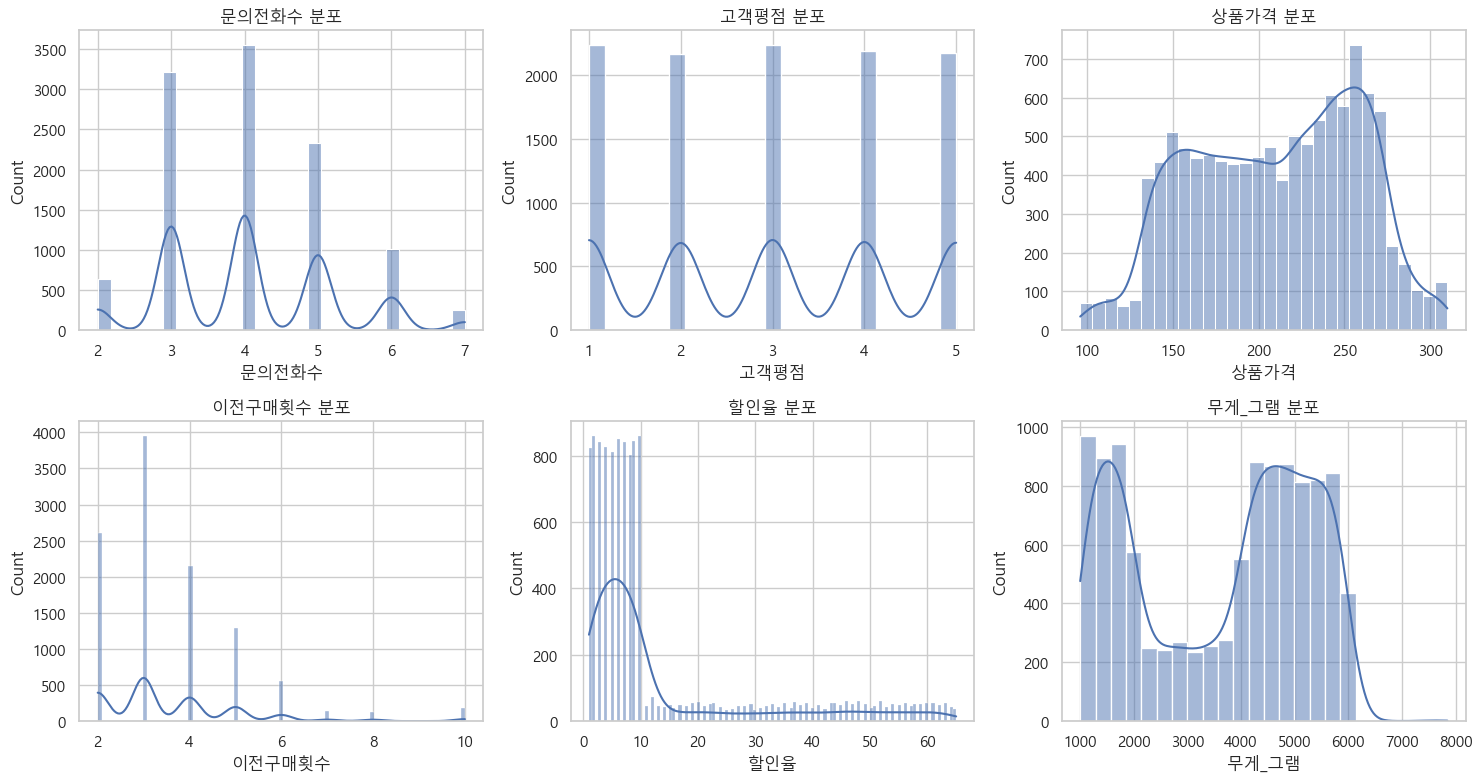

In [ ]:
# 수치형 변수 선택
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# subplot 크기 설정 (컬럼 수에 따라 자동 조정)
n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

# figure 생성
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

# 각 변수별 히스토그램
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"{col} 분포")

# 남는 subplot 제거
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


**해석:** 문의전화수와 고객평점은 이산형 분포로 특정 값(3 ~ 5, 2 ~ 4)에 집중되어 있다.
상품가격과 무게는 비교적 넓게 퍼져 있으며, 특히 무게는 이중 피크 형태로 구간별 특성이 다르다.
이전구매횟수는 낮은 값에 치우친 분포이고, 할인율은 저할인 구간에 집중되면서 일부 고할인 이상값이 존재한다.

### 과제 2-2. 수치형 변수 각각에 대해 `배송결과`별 박스플롯을 그려 비교하시오.

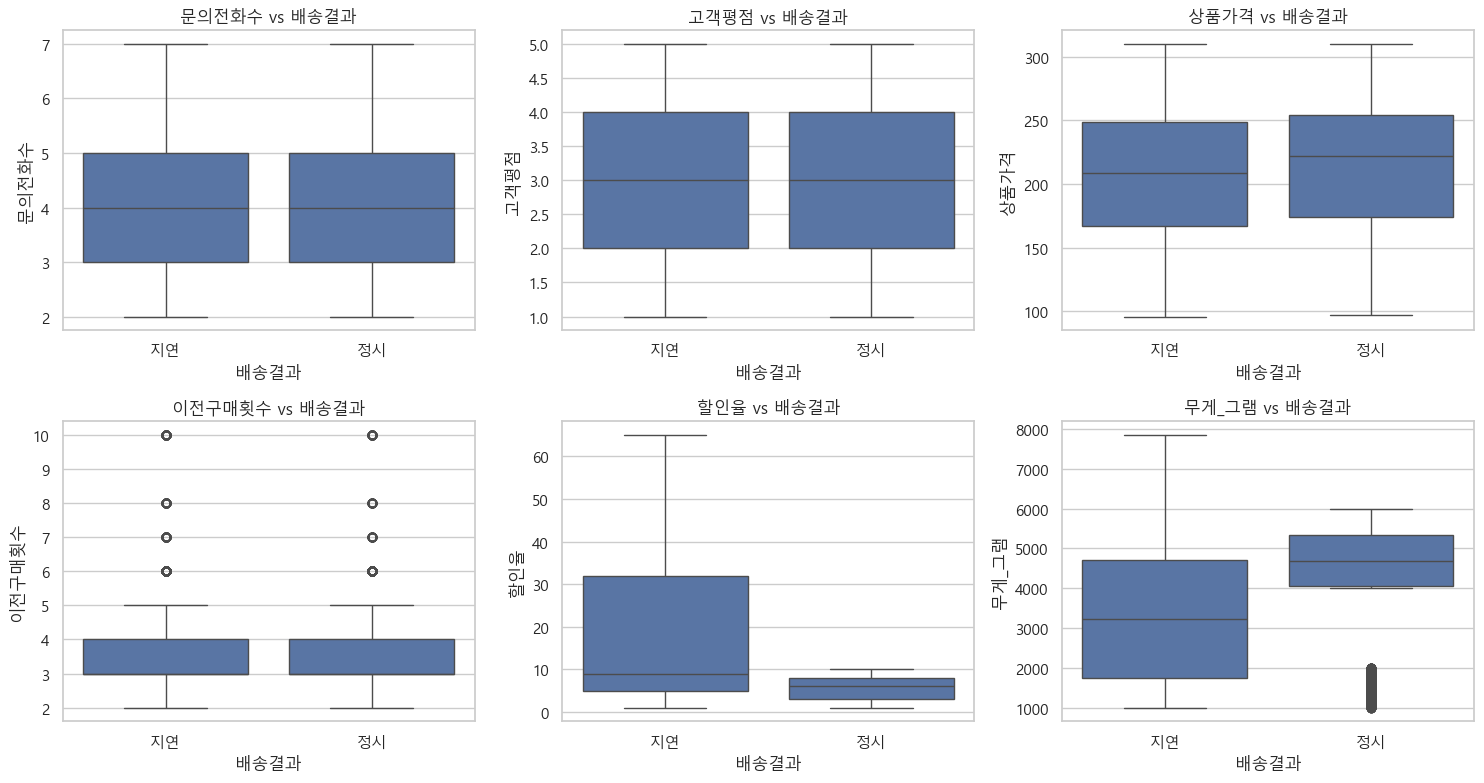

In [ ]:
# 수치형 변수 선택
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# subplot 구성
n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

# 박스플롯
for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='배송결과', y=col, ax=axes[i])
    axes[i].set_title(f"{col} vs 배송결과")

# 남는 subplot 제거
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


**해석:** 문의전화수, 고객평점, 이전구매횟수는 정시/지연 간 분포 차이가 거의 없어 영향력이 제한적으로 보입니다.
반면 할인율은 지연 그룹에서 훨씬 높고 분산도 커서, 지연을 유발하는 가장 강력한 요인으로 보입니다.
무게는 정시가 오히려 더 높은 경향이 있어 단순히 “무거울수록 지연”이라고 보기는 어렵고, 배송수단과의 결합 효과를 의심해야 합니다.

### 과제 2-3. 범주형 변수 각각에 대해 `배송결과`별 빈도를 비교하시오.

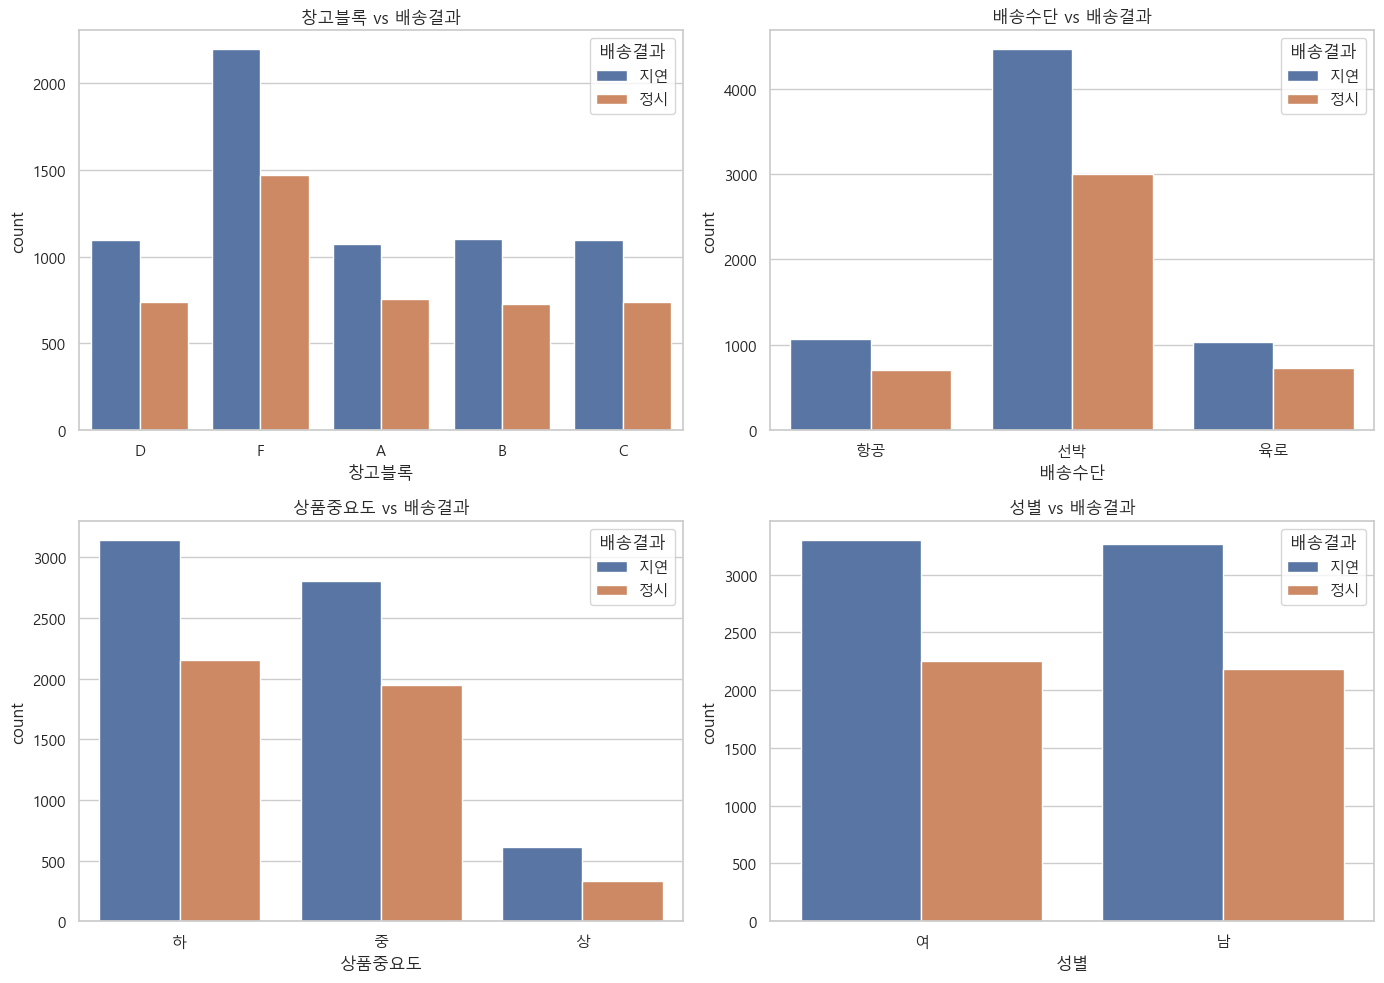

In [ ]:
# 범주형 변수
cat_cols = ['창고블록', '배송수단', '상품중요도', '성별']

# subplot 설정
n_cols = 2
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

# 시각화
for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue='배송결과', ax=axes[i])
    axes[i].set_title(f"{col} vs 배송결과")
    axes[i].legend(title='배송결과')

# 남는 subplot 제거
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


**해석:** 배송지연은 성별 같은 고객 특성보다 배송수단·상품중요도 등 물류 변수의 영향을 더 크게 받는다.
특히 선박 배송과 중요도가 낮은 상품에서 지연이 많이 발생하는 경향이 있다.
창고블록은 물량 차이에 따른 영향은 있으나, 구조적 원인은 물류 운영 측면에 있다.

### 과제 2-4. 핵심 변수로 보이는 `할인율`을 자세히 들여다보시오. 할인율 구간별(5%단위 구간) 지연 비율을 표와 그래프로 확인.

   할인율_구간      지연여부
0     0~5  0.475949
1    5~10  0.463691
2   10~15  0.568203
3   15~20  1.000000
4   20~25  1.000000
5   25~30  1.000000
6   30~35  1.000000
7   35~40  1.000000
8   40~45  1.000000
9   45~50  1.000000
10  50~55  1.000000
11  55~60  1.000000
12  60~65  1.000000


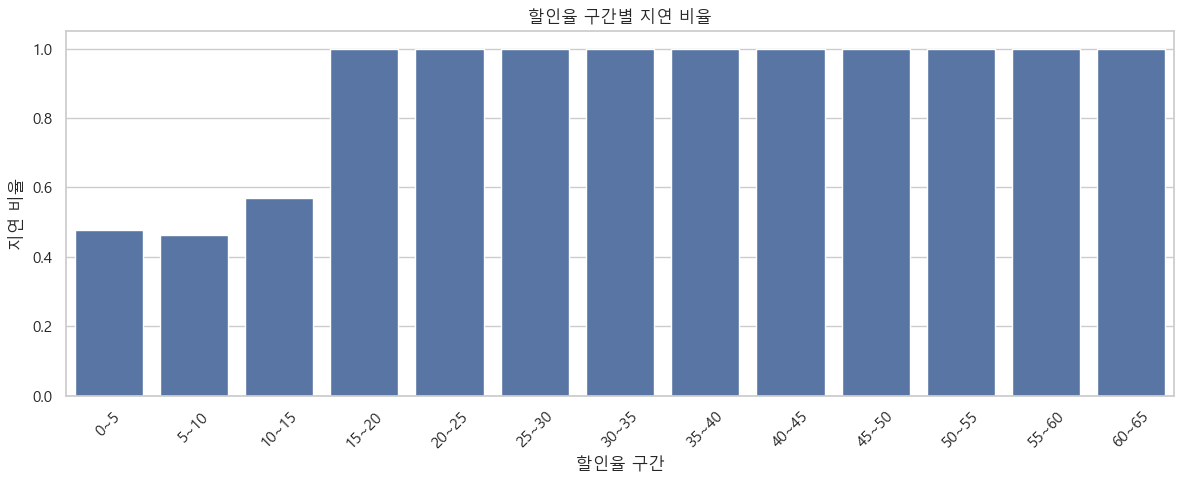

In [ ]:
# 1. 할인율 구간 생성 (5% 단위)
bins = range(0, 70, 5)  # 최대값 65 고려
labels = [f"{i}~{i+5}" for i in bins[:-1]]

df['할인율_구간'] = pd.cut(df['할인율'], bins=bins, labels=labels, right=False)

# 2. 지연 여부 이진화
df['지연여부'] = (df['배송결과'] == '지연').astype(int)

# 3. 구간별 지연 비율 계산
delay_rate = df.groupby('할인율_구간')['지연여부'].mean().reset_index()

# 4. 표 출력
print(delay_rate)

# ------------------------------
# 5. 시각화
plt.figure(figsize=(12, 5))
sns.barplot(data=delay_rate, x='할인율_구간', y='지연여부')

plt.xticks(rotation=45)
plt.title("할인율 구간별 지연 비율")
plt.ylabel("지연 비율")
plt.xlabel("할인율 구간")

plt.tight_layout()
plt.show()

**해석**: 할인율이 15%를 넘는 순간 지연 비율이 100%로 급격히 상승하며, 명확한 임계값이 존재한다.
즉, 고할인 정책 자체가 물류 지연을 유발하는 구조적 원인일 가능성이 매우 높다.
실무적으로는 할인율 상한을 설정하거나, 고할인 주문에 별도 물류 대응 전략이 필요하다.

### 과제 2-5. 또 다른 핵심 변수인 `무게_그램`을 자세히 들여다보시오. 무게 구간별 지연 비율을 확인.

                무게_구간      지연여부
0  (1000.999, 1677.6]  0.677273
1    (1677.6, 3319.8]  0.847273
2    (3319.8, 4512.0]  0.611540
3    (4512.0, 5245.8]  0.420837
4    (5245.8, 7846.0]  0.426364


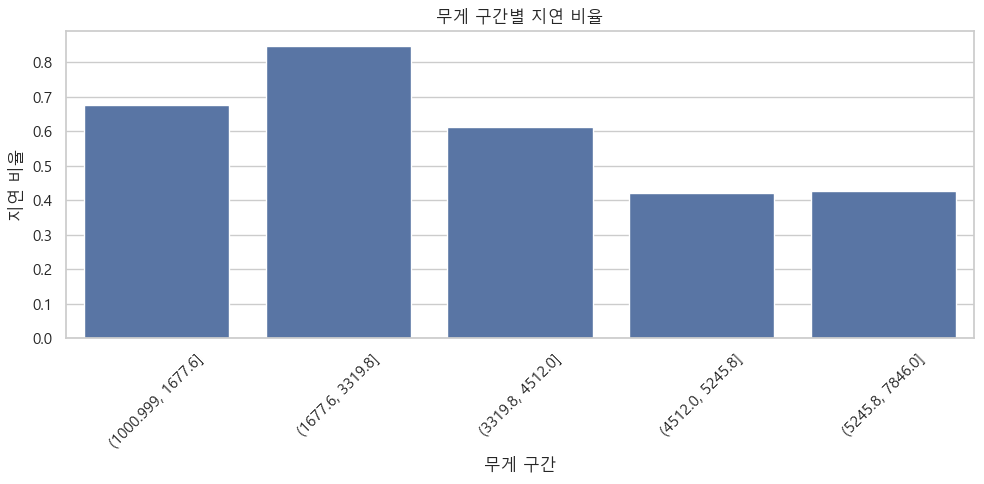

In [ ]:
# 1. 무게 구간 생성 (분위수 기반 5구간)
df['무게_구간'] = pd.qcut(df['무게_그램'], q=5)

# 2. 지연 여부 이진화
df['지연여부'] = (df['배송결과'] == '지연').astype(int)

# 3. 구간별 지연 비율 계산
weight_delay = df.groupby('무게_구간')['지연여부'].mean().reset_index()

# 4. 표 출력
print(weight_delay)

# ------------------------------
# 5. 시각화
plt.figure(figsize=(10, 5))
sns.barplot(data=weight_delay, x='무게_구간', y='지연여부')

plt.xticks(rotation=45)
plt.title("무게 구간별 지연 비율")
plt.ylabel("지연 비율")
plt.xlabel("무게 구간")

plt.tight_layout()
plt.show()


**해석**: 중간 무게 구간(약 1,600~3,300g)에서 지연 비율이 가장 높고, 오히려 더 무거운 구간에서는 지연이 감소한다.
즉, “무거울수록 지연”이 아니라 특정 무게대에서 물류 처리 비효율이나 병목이 발생하는 구조로 보인다.
실무적으로는 해당 중간 무게 구간에 대한 포장·운송 프로세스 점검이 필요하다.

### 과제 2-6. 두 핵심 변수(할인율, 무게)를 동시에 보는 산점도를 그려, 결과별로 색을 다르게 해 패턴을 확인하시오.

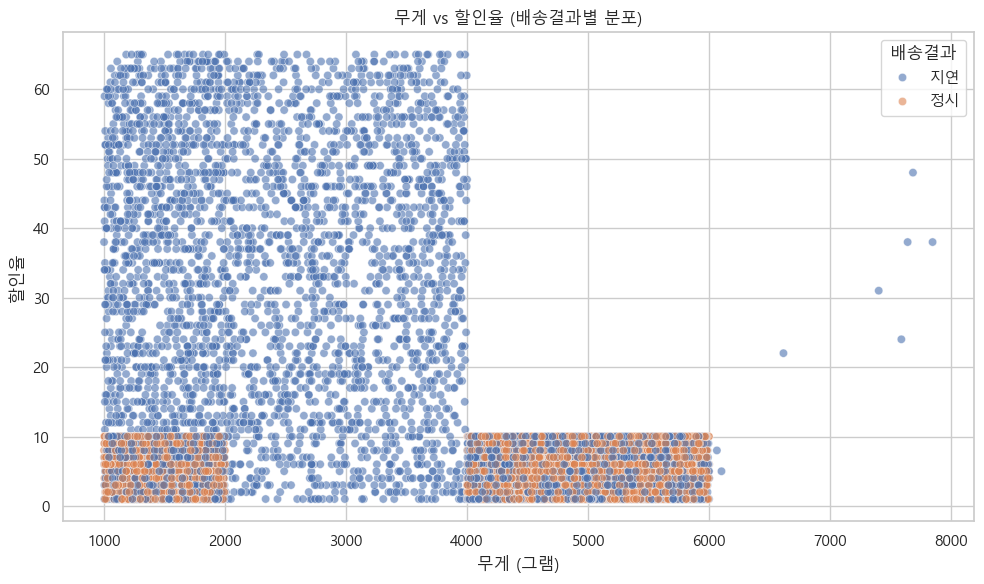

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='무게_그램',
    y='할인율',
    hue='배송결과',
    alpha=0.6
)

plt.title("무게 vs 할인율 (배송결과별 분포)")
plt.xlabel("무게 (그램)")
plt.ylabel("할인율")

plt.legend(title='배송결과')
plt.tight_layout()
plt.show()


**해석:** 할인율이 10 ~ 15% 이상으로 올라가는 구간에서는 거의 모든 데이터가 지연으로 나타나며, 무게와 무관하게 강한 영향력을 보인다.
정시 배송은 대부분 낮은 할인율(약 0~10%) 구간에 집중되어 있어, 할인율이 핵심 결정 변수임이 명확하다.
무게는 단독 영향보다 할인율과 결합될 때 의미가 있으며, 특히 중저가 무게 구간에서 고할인 시 지연이 집중된다.

### 과제 2-7. 수치형 변수들 간의 상관관계를 히트맵으로 확인하시오. (`배송결과`도 0/1로 변환해 포함)

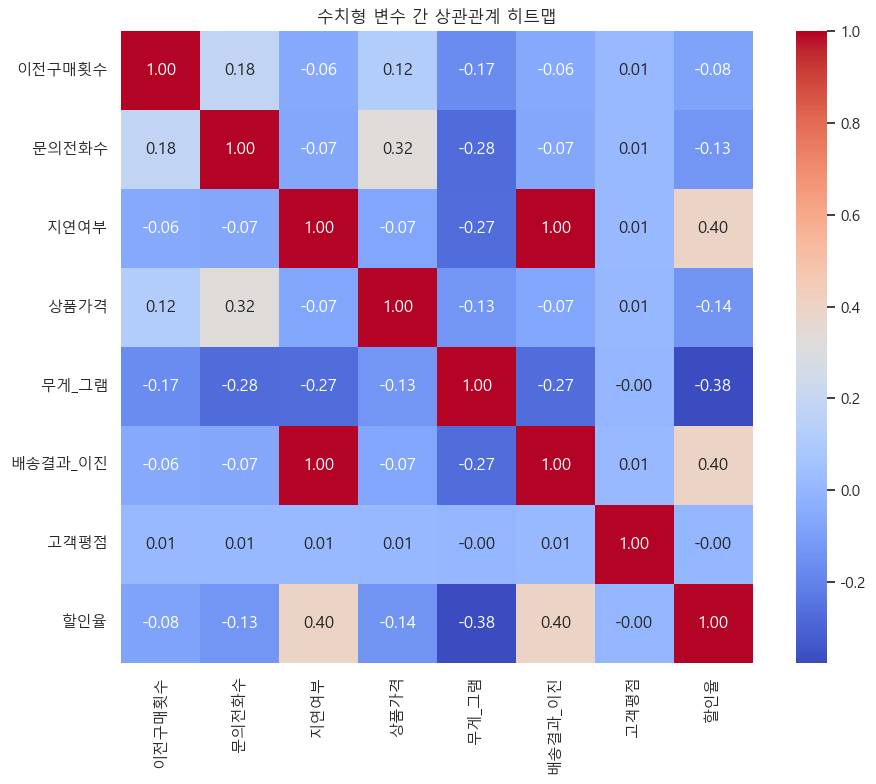

In [ ]:
# 배송결과 이진화
df['배송결과_이진'] = df['배송결과'].map({'정시': 0, '지연': 1})

# 수치형 변수만 선택 (타겟 포함)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols.append('배송결과_이진')

# 중복 제거 (이미 포함된 경우 대비)
num_cols = list(set(num_cols))

# 상관계수 계산
corr = df[num_cols].corr()

# 히트맵 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)

plt.title("수치형 변수 간 상관관계 히트맵")
plt.tight_layout()
plt.show()


**해석:** 할인율이 배송지연과 가장 높은 양의 상관관계(≈0.40)를 보여, 지연을 설명하는 핵심 변수로 확인된다.
무게는 배송지연과 음의 상관(≈-0.27)을 보여 단순히 무거울수록 지연된다는 가설은 성립하지 않는다.
그 외 변수들은 상관계수가 매우 낮아, 배송지연은 일부 핵심 변수(특히 할인율)에 의해 주로 설명되는 구조다.

---
## 3. 인사이트 정리 (약 5분)

### 과제 3-1. 지금까지의 탐색 결과를 표로 정리하시오. 어떤 피처가 강한 시그널이고 어떤 피처가 약한지 평가.

In [ ]:
summary_df = pd.DataFrame({
    "변수": [
        "할인율", "무게_그램", "배송수단", "상품중요도",
        "창고블록", "상품가격", "문의전화수", "이전구매횟수",
        "고객평점", "성별"
    ],
    "유형": [
        "수치형", "수치형", "범주형", "범주형",
        "범주형", "수치형", "수치형", "수치형",
        "수치형", "범주형"
    ],
    "지연과의 관계": [
        "강한 양의 관계", "비선형 관계", "선박에서 지연 많음", "낮을수록 지연 증가",
        "일부 편차 존재", "약한 관계", "거의 없음", "거의 없음",
        "없음", "없음"
    ],
    "시그널 강도": [
        "★★★★★", "★★★★☆", "★★★★☆", "★★★★☆",
        "★★☆☆☆", "★★☆☆☆", "★☆☆☆☆", "★☆☆☆☆",
        "★☆☆☆☆", "★☆☆☆☆"
    ],
    "해석": [
        "15% 이상에서 지연 급증",
        "특정 구간에서 지연 증가",
        "운송 특성 영향",
        "우선순위 처리 영향",
        "물량 영향 가능성",
        "직접 영향 미미",
        "설명력 낮음",
        "영향 미미",
        "의미 없음",
        "완전 무관"
    ],
    "룰베이스 후보": [
        "가능", "조건부", "가능", "가능",
        "조건부", "불가", "불가", "불가",
        "불가", "불가"
    ]
})

display(summary_df)


,변수,유형,지연과의 관계,시그널 강도,해석,룰베이스 후보
0,할인율,수치형,강한 양의 관계,★★★★★,15% 이상에서 지연 급증,가능
1,무게_그램,수치형,비선형 관계,★★★★☆,특정 구간에서 지연 증가,조건부
2,배송수단,범주형,선박에서 지연 많음,★★★★☆,운송 특성 영향,가능
3,상품중요도,범주형,낮을수록 지연 증가,★★★★☆,우선순위 처리 영향,가능
4,창고블록,범주형,일부 편차 존재,★★☆☆☆,물량 영향 가능성,조건부
5,상품가격,수치형,약한 관계,★★☆☆☆,직접 영향 미미,불가
6,문의전화수,수치형,거의 없음,★☆☆☆☆,설명력 낮음,불가
7,이전구매횟수,수치형,거의 없음,★☆☆☆☆,영향 미미,불가
8,고객평점,수치형,없음,★☆☆☆☆,의미 없음,불가
9,성별,범주형,없음,★☆☆☆☆,완전 무관,불가


**해석:** 할인율은 가장 강력한 변수로, 특정 임계값을 기준으로 지연을 거의 결정짓는 수준이다.
배송수단과 상품중요도는 물류 운영 관점에서 지연을 설명하는 핵심 보조 변수다.
무게는 단순 선형 관계가 아니라 특정 구간에서만 영향이 나타나는 비선형 변수다.
그 외 고객 관련 변수(성별, 평점, 구매횟수 등)는 지연과 거의 무관하다.
전체적으로 지연은 고객 특성보다 할인 정책과 물류 구조에 의해 결정되는 패턴이다.

---
## 4. 룰 도출 및 검증

### 과제 4-1. 위 인사이트를 바탕으로 두 가지 룰을 정의하고, 각각의 정확도를 베이스라인(항상 지연으로 예측하는 모델)과 비교하시오.

In [ ]:
# 베이스라인: 항상 '지연'으로 예측
baseline_acc = (df['배송결과'] == '지연').mean()
print("Baseline Accuracy:", baseline_acc)

df['rule1_pred'] = df['할인율'].apply(lambda x: '지연' if x >= 15 else '정시')
rule1_acc = (df['rule1_pred'] == df['배송결과']).mean()
print("Rule 1 Accuracy:", rule1_acc)

df['rule2_pred'] = df.apply(
    lambda row: '지연' if (
        row['할인율'] >= 15 or
        (row['배송수단'] == '선박' and row['상품중요도'] == '하')
    ) else '정시',
    axis=1
)
rule2_acc = (df['rule2_pred'] == df['배송결과']).mean()
print("Rule 2 Accuracy:", rule2_acc)

print("\n=== Accuracy 비교 ===")
print(f"Baseline (항상 지연): {baseline_acc:.4f}")
print(f"Rule 1: {rule1_acc:.4f}")
print(f"Rule 2: {rule2_acc:.4f}")

Baseline Accuracy: 0.5966906082371125
Rule 1 Accuracy: 0.6255114101281934
Rule 2 Accuracy: 0.6156923356668788

=== Accuracy 비교 ===
Baseline (항상 지연): 0.5967
Rule 1: 0.6255
Rule 2: 0.6157


In [ ]:
df['rule_weight_pred'] = df['무게_그램'].apply(
    lambda x: '지연' if 1600 <= x <= 3300 else '정시'
)

weight_rule_acc = (df['rule_weight_pred'] == df['배송결과']).mean()
print("Weight Rule Accuracy:", weight_rule_acc)

print("\n=== Accuracy 비교 ===")
print(f"Baseline: {baseline_acc:.4f}")
print(f"Rule 1 (할인율): {rule1_acc:.4f}")
print(f"Weight Rule: {weight_rule_acc:.4f}")

Weight Rule Accuracy: 0.5493226656968815

=== Accuracy 비교 ===
Baseline: 0.5967
Rule 1 (할인율): 0.6255
Weight Rule: 0.5493


**해석:** 무게 단독 룰은 baseline보다 낮은 정확도를 보여, 지연을 설명하는 핵심 변수로는 부족하다.
즉, 무게는 독립적으로 사용하기보다 다른 변수와 결합해야 의미가 있다.
결론적으로 할인율이 지연 예측의 핵심 변수이며, 무게는 보조적 역할에 그친다.

### 과제 4-2. 두 룰을 OR 조건으로 결합하여 최종 룰을 만들고, 정확도와 혼동행렬, 정밀도/재현율을 확인하시오.

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ---------------------------
# 1. 최종 룰 정의 (OR 결합)
# ---------------------------
df['final_rule_pred'] = df.apply(
    lambda row: '지연' if (
        row['할인율'] >= 15 or
        (1600 <= row['무게_그램'] <= 3300)
    ) else '정시',
    axis=1
)

# ---------------------------
# 2. 정확도
# ---------------------------
acc = accuracy_score(df['배송결과'], df['final_rule_pred'])
print("Final Rule Accuracy:", acc)

# ---------------------------
# 3. 혼동행렬
# ---------------------------
cm = confusion_matrix(df['배송결과'], df['final_rule_pred'], labels=['정시', '지연'])
print("\nConfusion Matrix:")
print(cm)

# ---------------------------
# 4. 정밀도 / 재현율 / F1-score
# ---------------------------
print("\nClassification Report:")
print(classification_report(df['배송결과'], df['final_rule_pred']))


Final Rule Accuracy: 0.6536957905264115

Confusion Matrix:
[[4017  419]
 [3390 3173]]

Classification Report:
              precision    recall  f1-score   support

          정시       0.54      0.91      0.68      4436
          지연       0.88      0.48      0.62      6563

    accuracy                           0.65     10999
   macro avg       0.71      0.69      0.65     10999
weighted avg       0.75      0.65      0.65     10999



**해석:**
정확도는 0.65로 baseline(0.60) 대비 분명히 개선됐지만, 구조적으로 한쪽으로 치우친 성능입니다.
정시 recall이 0.91로 매우 높은 대신, 지연 recall이 0.48로 절반 정도만 잡고 있어 지연 탐지 성능은 부족합니다.
반대로 지연 precision은 0.88이라 “지연이라고 찍은 건 대부분 맞지만, 많이 놓치는” 보수적인 룰입니다.
즉 현재 룰은 정시를 잘 걸러내는 필터로는 쓸 수 있지만, 지연을 적극적으로 탐지하는 용도로는 한계가 있습니다.

---
## 5. 잔여 영역 심화 분석

### 배경
룰1 + 룰2는 지연 recall 0.444에 불과하다. 산점도에서 두 룰이 못 잡는 영역에 정시와 지연이 섞여 있었다. 그 영역을 다시 들여다보면 추가 룰이 나올지 확인한다.

### 과제 5-1. 룰1, 룰2 둘 다 적용되지 않는 "잔여 영역"의 데이터를 추출하고 그 크기와 지연율을 확인하시오.

In [ ]:
# ---------------------------
# 1. 잔여 영역 정의
# ---------------------------
residual_df = df[
    ~(
        (df['할인율'] >= 15) |
        ((df['무게_그램'] >= 1600) & (df['무게_그램'] <= 3300))
    )
]

# ---------------------------
# 2. 크기 확인
# ---------------------------
print("잔여 데이터 크기:", residual_df.shape)

# ---------------------------
# 3. 지연율 계산
# ---------------------------
delay_rate = (residual_df['배송결과'] == '지연').mean()
print("잔여 영역 지연율:", delay_rate)


잔여 데이터 크기: (7407, 19)
잔여 영역 지연율: 0.4576751721344674


**해석:** 잔여 영역이 전체의 상당 부분(약 67%)을 차지한다는 점에서, 현재 룰이 커버하는 범위는 제한적입니다.
이 영역의 지연율이 약 45.8%로 전체 평균(약 59.7%)보다 낮아, 핵심 지연 케이스는 기존 룰이 어느 정도 잘 잡아낸 것으로 보입니다.
다만 여전히 절반 가까이가 지연이기 때문에, 추가 룰만으로 해결하기보다는 모델 기반 접근이 필요한 구간입니다.

### 과제 5-2. 잔여 영역을 무게 기준으로 두 부분으로 분해하고 각각의 지연율을 비교하시오.
- 영역 A: 무게 < 2kg AND 할인율 ≤ 10
- 영역 B: 무게 > 4kg

In [ ]:
# ---------------------------
# 1. 영역 A / B 정의 (잔여 영역 기준)
# ---------------------------
area_A = residual_df[
    (residual_df['무게_그램'] < 2000) &
    (residual_df['할인율'] <= 10)
]

area_B = residual_df[
    (residual_df['무게_그램'] > 4000)
]

# ---------------------------
# 2. 각 영역 크기
# ---------------------------
print("Area A 크기:", area_A.shape)
print("Area B 크기:", area_B.shape)

# ---------------------------
# 3. 지연율 계산
# ---------------------------
delay_A = (area_A['배송결과'] == '지연').mean()
delay_B = (area_B['배송결과'] == '지연').mean()

print("\nArea A 지연율:", delay_A)
print("Area B 지연율:", delay_B)


Area A 크기: (1254, 19)
Area B 크기: (5960, 19)

Area A 지연율: 0.5
Area B 지연율: 0.4313758389261745


**해석:** 잔여 영역에서도 두 구간 모두 지연율이 50% 내외로, 뚜렷하게 구분되는 패턴이 없다.
특히 무게 > 4kg 구간은 오히려 지연율이 더 낮아, 무게 기반 추가 룰의 효과는 제한적이다.
즉, 잔여 영역은 단순 룰로 분리하기 어려운 구간이며 모델 기반 접근이 필요한 영역이다.

### 과제 5-3. 영역 A에서 각 변수별 지연 비율을 막대그래프로 비교하여 시그널이 있는 변수를 찾으시오.
- 변수: ['문의전화수', '고객평점', '이전구매횟수', '상품중요도', '배송수단', '창고블록']

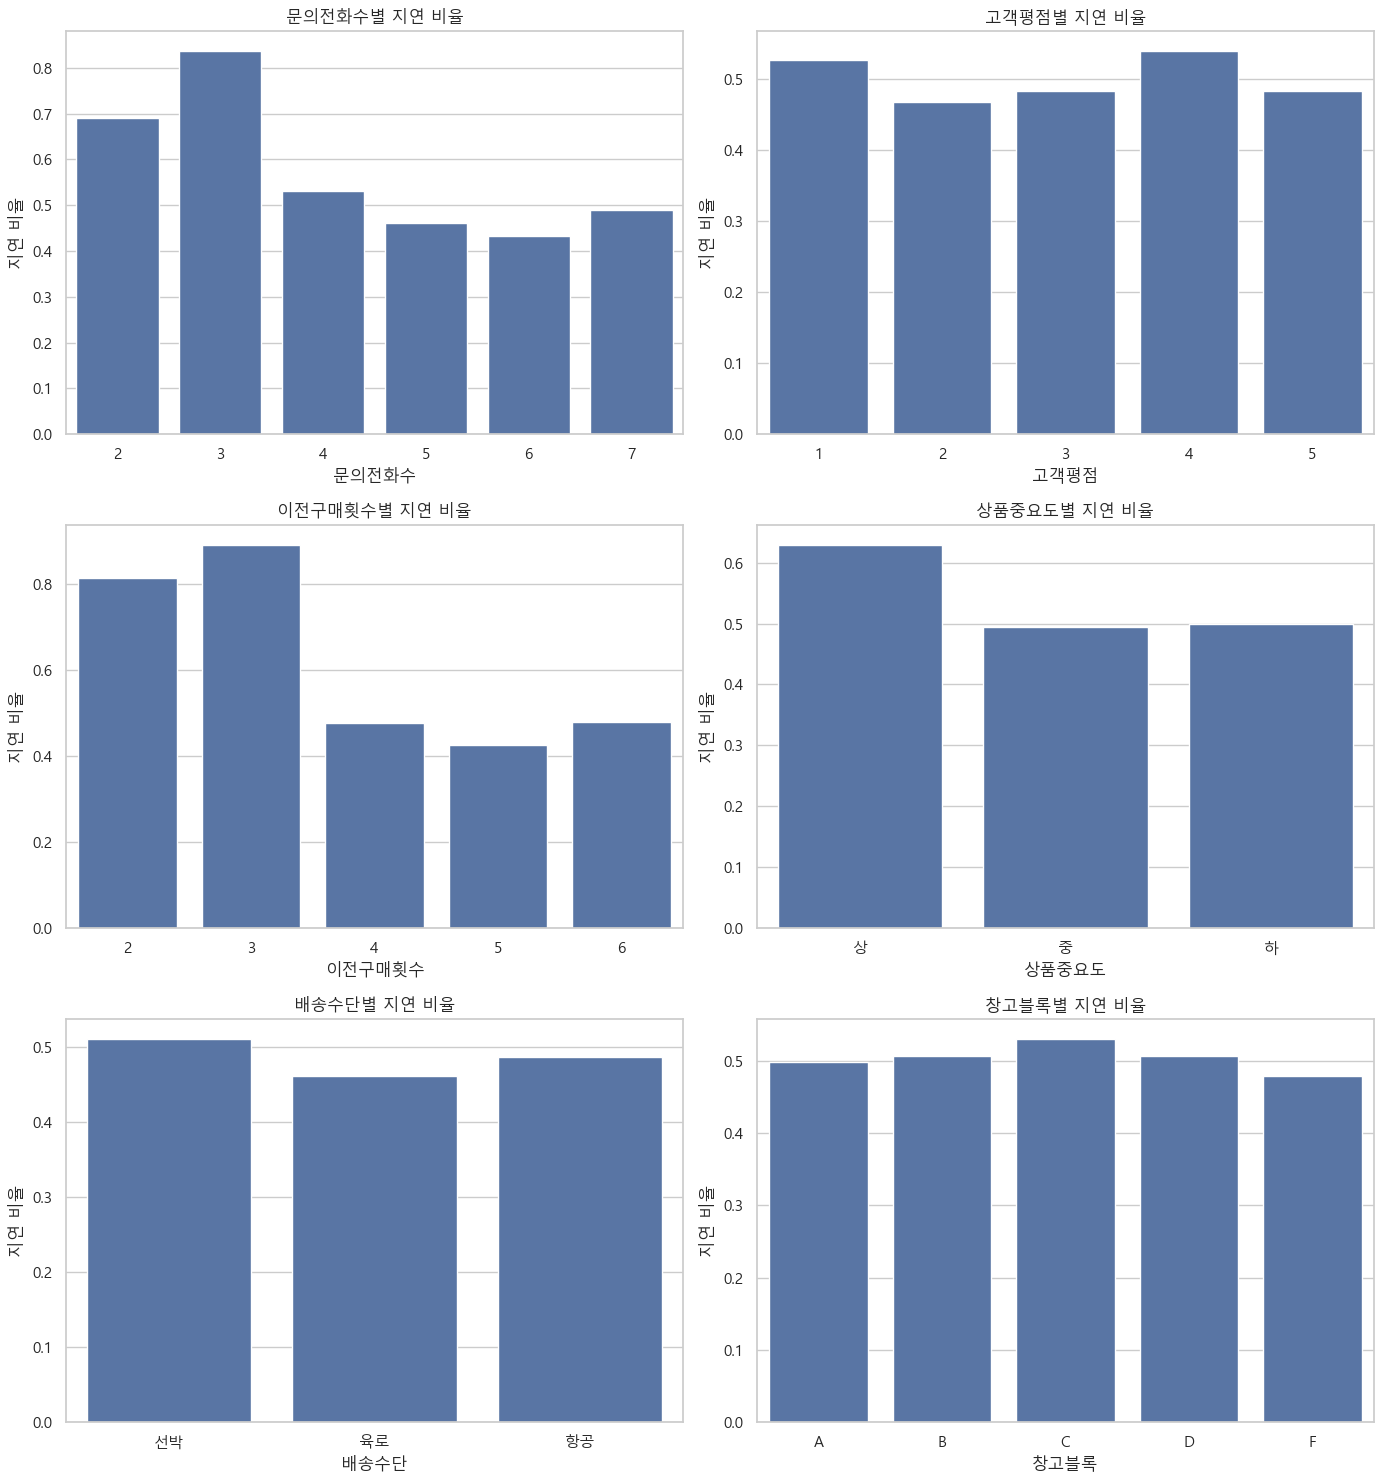

In [ ]:
# 분석할 변수
cols = ['문의전화수', '고객평점', '이전구매횟수', '상품중요도', '배송수단', '창고블록']

# 지연 여부 이진화 (이미 있으면 생략)
area_A['지연여부'] = (area_A['배송결과'] == '지연').astype(int)

# subplot 설정
n_cols = 2
n_rows = (len(cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

# 변수별 지연 비율 시각화
for i, col in enumerate(cols):
    temp = area_A.groupby(col)['지연여부'].mean().reset_index()

    sns.barplot(data=temp, x=col, y='지연여부', ax=axes[i])
    axes[i].set_title(f"{col}별 지연 비율")
    axes[i].set_ylabel("지연 비율")
    axes[i].set_xlabel(col)

# 남는 subplot 제거
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


**해석:** 문의전화수와 이전구매횟수에서 뚜렷한 패턴이 보이며, 값이 낮을수록 지연 비율이 높아지는 경향이 있다.
상품중요도는 ‘상’일 때 지연 비율이 높아 우선순위 상품이 오히려 지연 리스크가 있는 신호로 보인다.
반면 배송수단, 창고블록, 고객평점은 지연 비율 차이가 크지 않아 추가 룰 변수로서의 영향력은 제한적이다.

### 과제 5-4. 영역 A 내 이전구매횟수별 지연 비율을 정확히 표로 확인하시오.

In [ ]:
# 지연 여부 이진화 (이미 있으면 생략)
area_A['지연여부'] = (area_A['배송결과'] == '지연').astype(int)

# 이전구매횟수별 지연 비율 + 건수
purchase_delay_table = (
    area_A
    .groupby('이전구매횟수')
    .agg(
        지연비율=('지연여부', 'mean'),
        건수=('지연여부', 'count')
    )
    .sort_values(by='지연비율', ascending=False)
)

print(purchase_delay_table)


            지연비율   건수
이전구매횟수               
3       0.891566   83
2       0.813559   59
6       0.478261  115
4       0.475915  519
5       0.424686  478


**해석:** 이전구매횟수 2 ~ 3회 구간에서 지연 비율이 80~90%로 매우 높아, 강한 위험 신호로 작동한다.
반면 4회 이상부터는 지연 비율이 40%대로 급격히 낮아지며 안정 구간으로 전환된다.
즉, “초기 재구매 고객(2 ~ 3회)”이 핵심 지연 리스크 집단으로 해석된다.

### 과제 5-5. 영역 B에서도 같은 방법으로 변수별 지연 비율을 확인하시오.

In [ ]:
# 지연 여부 이진화 (이미 있으면 생략)
area_B['지연여부'] = (area_B['배송결과'] == '지연').astype(int)

cols = ['문의전화수', '고객평점', '이전구매횟수', '상품중요도', '배송수단', '창고블록']

for col in cols:
    print(f"\n=== {col}별 지연 비율 ===")

    table = (
        area_B
        .groupby(col)
        .agg(
            지연비율=('지연여부', 'mean'),
            건수=('지연여부', 'count')
        )
        .sort_values(by='지연비율', ascending=False)
    )

    print(table)



=== 문의전화수별 지연 비율 ===
           지연비율    건수
문의전화수                
5      0.450303  1157
6      0.439216   255
4      0.428239  2146
3      0.425646  2051
2      0.415954   351

=== 고객평점별 지연 비율 ===
          지연비율    건수
고객평점                
3     0.453871  1214
5     0.447826  1150
4     0.426948  1232
1     0.416190  1223
2     0.411919  1141

=== 이전구매횟수별 지연 비율 ===
            지연비율    건수
이전구매횟수                
8       0.500000    90
7       0.488372    86
3       0.445935  2534
6       0.434263   251
2       0.422749  1644
4       0.411246   907
5       0.398148   324
10      0.387097   124

=== 상품중요도별 지연 비율 ===
           지연비율    건수
상품중요도                
상      0.479339   605
하      0.428518  2693
중      0.423366  2662

=== 배송수단별 지연 비율 ===
          지연비율    건수
배송수단                
항공    0.448916   969
육로    0.434333   967
선박    0.426441  4024

=== 창고블록별 지연 비율 ===
          지연비율    건수
창고블록                
B     0.435484   992
F     0.433753  1985
D     0.432596   994
C     0.432432   99

**해석:** 영역 B에서는 대부분 변수의 지연 비율이 0.42 ~ 0.45 수준에 밀집되어 있어 뚜렷한 분리력이 없다.
일부 값(이전구매횟수 7 ~ 8, 상품중요도 ‘상’)이 상대적으로 높지만, 전체 패턴을 뒤집을 정도의 강한 시그널은 아니다.
즉, 이 구간은 룰 기반으로 추가 분리하기 어렵고, 모델 기반 접근이 필요한 전형적인 저신호 영역이다.

### 과제 5-6. 영역 A에서 발견한 시그널을 바탕으로 룰3을 정의하고, 기존 두 룰과 결합한 최종 성능을 평가하시오.

**룰3: 무게 < 2kg AND 할인율 ≤ 10 AND 이전구매횟수 ≤ 3 → 지연**

In [ ]:
# ---------------------------
# Final Rule 정의
# ---------------------------
df['final_rule_v2_pred'] = df.apply(
    lambda row: '지연' if (
        (row['할인율'] >= 15) or
        (1600 <= row['무게_그램'] <= 3300) or
        (
            (row['무게_그램'] < 2000) and
            (row['할인율'] <= 10) and
            (row['이전구매횟수'] <= 3)
        )
    ) else '정시',
    axis=1
)

# ---------------------------
# 평가
# ---------------------------
acc = accuracy_score(df['배송결과'], df['final_rule_v2_pred'])
print("Final Rule v2 Accuracy:", acc)

# 혼동행렬
cm = confusion_matrix(df['배송결과'], df['final_rule_v2_pred'], labels=['정시', '지연'])
print("\nConfusion Matrix:")
print(cm)

# 정밀도 / 재현율
print("\nClassification Report:")
print(classification_report(df['배송결과'], df['final_rule_v2_pred']))


Final Rule v2 Accuracy: 0.6629693608509865

Confusion Matrix:
[[3997  439]
 [3268 3295]]

Classification Report:
              precision    recall  f1-score   support

          정시       0.55      0.90      0.68      4436
          지연       0.88      0.50      0.64      6563

    accuracy                           0.66     10999
   macro avg       0.72      0.70      0.66     10999
weighted avg       0.75      0.66      0.66     10999



**해석:** 정확도는 0.663으로 소폭 개선됐고, 특히 지연 recall이 0.48 → 0.50으로 올라가면서 일부 놓치던 케이스를 회수했습니다.
다만 precision은 유지되면서도 여전히 지연 recall이 낮아, “지연을 적극적으로 잡는 모델”로 보기에는 한계가 있습니다.
결국 추가 룰은 미세 개선 수준에 그치고 있어, 이 구간부터는 룰 확장보다 모델 기반 접근으로 넘어가는 것이 효율적인 단계입니다.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Baseline (항상 지연)
df['baseline_pred'] = '지연'

# Rule 2 (할인율 + 무게)
df['rule2_pred'] = df.apply(
    lambda row: '지연' if (
        (row['할인율'] >= 15) or
        (1600 <= row['무게_그램'] <= 3300)
    ) else '정시',
    axis=1
)

# Rule 3 (최종 v2)
df['rule3_pred'] = df.apply(
    lambda row: '지연' if (
        (row['할인율'] >= 15) or
        (1600 <= row['무게_그램'] <= 3300) or
        (
            (row['무게_그램'] < 2000) and
            (row['할인율'] <= 10) and
            (row['이전구매횟수'] <= 3)
        )
    ) else '정시',
    axis=1
)

# ---------------------------
# 2. 평가 함수
# ---------------------------
def evaluate(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision(지연)': precision_score(y_true, y_pred, pos_label='지연'),
        'Recall(지연)': recall_score(y_true, y_pred, pos_label='지연'),
        'F1(지연)': f1_score(y_true, y_pred, pos_label='지연')
    }

# ---------------------------
# 3. 결과 테이블 생성
# ---------------------------
results = pd.DataFrame([
    evaluate(df['배송결과'], df['baseline_pred']),
    evaluate(df['배송결과'], df['rule2_pred']),
    evaluate(df['배송결과'], df['rule3_pred'])
], index=['Baseline', 'Rule 2', 'Rule 3'])

display(results)

,Accuracy,Precision(지연),Recall(지연),F1(지연)
Baseline,0.596691,0.596691,1.000000,0.747409
Rule 2,0.653696,0.883352,0.483468,0.624914
Rule 3,0.662969,0.882432,0.502057,0.639992
